In [ ]:
import numpy as np
import csv
import os

In [ ]:
def get_data(csv_data):
  new_data = []   # Dimensions: [T, F]
  labels = []   # Dimensions: [T]

  for element in data[1:]:
      features = []
      all_features = True
      if (element[1] == ""):
          all_features = False
      else:
          labels.append(float(element[1]))
          for feature in element[2:]:
              if feature == "":
                  all_features = False
                  break
              features.append(float(feature))
      if all_features:
          new_data.append(features)

  return np.array(new_data), np.array(labels)

In [ ]:
def dwt_swt(x, dt=None, wavelet="db4", max_level=None, norm=True):
    t = np.arange(len(x))   # Dimensions: [T]
    if dt is None or not np.isfinite(dt) or dt <= 0:
        dt = 1.0
    fs = 1.0 / dt

    if max_level is None:
        max_level = pywt.swt_max_level(len(x))

    coeffs = pywt.swt(x, wavelet=wavelet, level=max_level, norm=norm)
    details = [cD for (cA, cD) in coeffs]

    return t, details

In [ ]:
def to_wavelets(data):
  new_data = []   # Dimensions: [T, F*(# levels)]
  for feature in range(len(data[0])):
      new_data.append(dwt_swt(data[:,feature]))

  new_data = np.reshape(new_data, [T, len(new_data[0])])
  return new_data

In [ ]:
def smart_correlation_feature_selection(data):
  target_feat = 4
  target_feats = [target_feat, target_feat+15, target_feat+30, target_feat+45, target_feat+60]
  X = np.delete(data, target_feats)
  y = data[target_feat]

  print(f"Original shape: {X.shape}")
  print(f"Features: {X.columns.tolist()}\n")

  # --- PIPELINE STEP 1: Smart Correlation Selection ---
  # Identify groups of correlated features and keeps the "best" one.
  print("--- Step 1: Smart Correlation Filtering ---")
  smart_corr = SmartCorrelatedSelection(
      variables=None,
      method="spearman",
      threshold=0.85,
      missing_values="ignore",
      selection_method="variance",
      estimator=None
  )

  X_smart = smart_corr.fit_transform(X)

  print(f"Correlated groups found: {len(smart_corr.correlated_feature_sets_)}")
  for group in smart_corr.correlated_feature_sets_:
      print(f" -> Group: {group}")

  print(f"Dropped features: {smart_corr.features_to_drop_}")
  print(f"New shape: {X_smart.shape}\n")

  # --- PIPELINE STEP 2: Model-Based Selection (RFE) ---
  # Use Random Forest to see which features predict Grid Power
  print("--- Step 2: Recursive Feature Elimination ---")
  model = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)

  rfe_selector = RecursiveFeatureElimination(
      estimator=model,
      scoring='r2',
      threshold=0.01,
      cv=3,
  )

  X_final = rfe_selector.fit_transform(X_smart, y)
  return [int(feat[1:]) for feat in X_final.columns.tolist()]

In [ ]:
all_features = []

def save_data(turbine_num):
    csv_reader = csv.reader(open(f'turbine_data/train/turbine_{turbine_num}.csv', mode='r', newline = ""))
    csv_data = list(csv_reader)
    data, labels = get_data(csv_data)

    wavelet_data = to_wavelets(data)
    data = np.concatenate([data, wavelet_data], axis=1)   # Dimensions: [T, F*(num_levels+1)]

    features_selected = smart_correlation_feature_selection(data)
    print("Selected features:", features_selected)
    data = data[:features_selected]   # Dimensions: [T, num_Fs_selected (usually 8 for normal, 65 for wavelets)]
    all_features.append(features_selected)

    try:
        os.mkdir(f"turbine_data/t{turbine_num}")
    except:
        pass
    np.save(f"turbine_data/t{turbine_num}/train.npy", np.array(data))
    np.save(f"turbine_data/t{turbine_num}/test.npy", np.array(data))
    np.save(f"turbine_data/t{turbine_num}/test_labels.npy", np.array(labels))

In [ ]:
for i in range(1,22):
  save_data(i)

In [ ]:
times_selected = dict()

for feat in range(75):
  times_selected[feat] = 0
for feat in all_features:
    times_selected[feat] += 1

times_selected = sorted(times_selected, key = lambda item: item[1])
print(times_selected)

In [ ]:
import os
import argparse

from torch.backends import cudnn
from utils.utils import *

from solver import Solver


def str2bool(v):
    return v.lower() in ('true')


def main(config):
    cudnn.benchmark = True
    if (not os.path.exists(config.model_save_path)):
        mkdir(config.model_save_path)
    solver = Solver(vars(config))

    if config.mode == 'train':
        solver.train()
    elif config.mode == 'test':
        solver.test()

    return solver

In [ ]:
parser = argparse.ArgumentParser()

parser.add_argument('--lr', type=float, default=2e-5)
parser.add_argument('--num_epochs', type=int, default=10)
parser.add_argument('--k', type=int, default=3)
parser.add_argument('--win_size', type=int, default=100)
parser.add_argument('--input_c', type=int, default=15)
parser.add_argument('--output_c', type=int, default=15)
parser.add_argument('--batch_size', type=int, default=1)
parser.add_argument('--pretrained_model', type=str, default=None)
parser.add_argument('--dataset', type=str, default='Custom')
parser.add_argument('--mode', type=str, default='test', choices=['train', 'test'])
parser.add_argument('--data_path', type=str, default='turbine_data/t1/')
parser.add_argument('--model_save_path', type=str, default='../turbine_checkpoints')
parser.add_argument('--anormly_ratio', type=float, default=4.00)

config = parser.parse_args(args=[])

# args = vars(config)
# print('------------ Options -------------')
# for k, v in sorted(args.items()):
#     print('%s: %s' % (str(k), str(v)))
# print('-------------- End ----------------')
main(config)

In [39]:
raw_data = """
Threshold: 0.0
TP: 2448
FP: 7552
TN: 0
FN: 0

Threshold: 0.050505050505050504
TP: 2376
FP: 7420
TN: 132
FN: 72

Threshold: 0.10101010101010101
TP: 2292
FP: 7252
TN: 300
FN: 156

Threshold: 0.15151515151515152
TP: 2196
FP: 6928
TN: 624
FN: 252

Threshold: 0.20202020202020202
TP: 2004
FP: 6340
TN: 1212
FN: 444

Threshold: 0.25252525252525254
TP: 1574
FP: 5402
TN: 2150
FN: 874

Threshold: 0.30303030303030304
TP: 1166
FP: 3742
TN: 3810
FN: 1282

Threshold: 0.35353535353535354
TP: 684
FP: 2184
TN: 5368
FN: 1764

Threshold: 0.40404040404040403
TP: 444
FP: 1104
TN: 6448
FN: 2004

Threshold: 0.45454545454545453
TP: 300
FP: 708
TN: 6844
FN: 2148

Threshold: 0.5050505050505051
TP: 252
FP: 492
TN: 7060
FN: 2196

Threshold: 0.5555555555555556
TP: 180
FP: 312
TN: 7240
FN: 2268

Threshold: 0.6060606060606061
TP: 132
FP: 228
TN: 7324
FN: 2316

Threshold: 0.6565656565656566
TP: 108
FP: 144
TN: 7408
FN: 2340

Threshold: 0.7070707070707071
TP: 60
FP: 132
TN: 7420
FN: 2388

Threshold: 0.7575757575757576
TP: 60
FP: 72
TN: 7480
FN: 2388

Threshold: 0.8080808080808081
TP: 36
FP: 36
TN: 7516
FN: 2412

Threshold: 0.8585858585858586
TP: 24
FP: 12
TN: 7540
FN: 2424

Threshold: 0.9090909090909091
TP: 12
FP: 12
TN: 7540
FN: 2436

Threshold: 0.9595959595959596
TP: 0
FP: 12
TN: 7540
FN: 2448

Threshold: 1.0101010101010102
TP: 0
FP: 0
TN: 7552
FN: 2448

Threshold: 1.0606060606060606
TP: 0
FP: 0
TN: 7552
FN: 2448
"""

In [40]:
raw_data_2 = """
Anomaly ratio: 1.0
TP: 0
FP: 99
TN: 7354
FN: 2448

Anomaly ratio: 3.020408163265306
TP: 1
FP: 299
TN: 7154
FN: 2447

Anomaly ratio: 5.040816326530612
TP: 27
FP: 473
TN: 6980
FN: 2421

Anomaly ratio: 7.061224489795918
TP: 79
FP: 621
TN: 6832
FN: 2369

Anomaly ratio: 9.081632653061224
TP: 165
FP: 735
TN: 6718
FN: 2283

Anomaly ratio: 11.102040816326529
TP: 298
FP: 802
TN: 6651
FN: 2150

Anomaly ratio: 13.122448979591836
TP: 424
FP: 876
TN: 6577
FN: 2024

Anomaly ratio: 15.142857142857142
TP: 554
FP: 946
TN: 6507
FN: 1894

Anomaly ratio: 17.163265306122447
TP: 660
FP: 1040
TN: 6413
FN: 1788

Anomaly ratio: 19.183673469387752
TP: 771
FP: 1129
TN: 6324
FN: 1677

Anomaly ratio: 21.204081632653057
TP: 872
FP: 1228
TN: 6225
FN: 1576

Anomaly ratio: 23.224489795918366
TP: 960
FP: 1340
TN: 6113
FN: 1488

Anomaly ratio: 25.24489795918367
TP: 1054
FP: 1446
TN: 6007
FN: 1394

Anomaly ratio: 27.265306122448976
TP: 1141
FP: 1559
TN: 5894
FN: 1307

Anomaly ratio: 29.285714285714285
TP: 1211
FP: 1689
TN: 5764
FN: 1237

Anomaly ratio: 31.30612244897959
TP: 1277
FP: 1823
TN: 5630
FN: 1171

Anomaly ratio: 33.326530612244895
TP: 1347
FP: 1953
TN: 5500
FN: 1101

Anomaly ratio: 35.3469387755102
TP: 1412
FP: 2088
TN: 5365
FN: 1036

Anomaly ratio: 37.367346938775505
TP: 1465
FP: 2235
TN: 5218
FN: 983

Anomaly ratio: 39.38775510204081
TP: 1522
FP: 2378
TN: 5075
FN: 926

Anomaly ratio: 41.408163265306115
TP: 1573
FP: 2527
TN: 4926
FN: 875

Anomaly ratio: 43.42857142857142
TP: 1620
FP: 2680
TN: 4773
FN: 828

Anomaly ratio: 45.44897959183673
TP: 1667
FP: 2833
TN: 4620
FN: 781

Anomaly ratio: 47.469387755102034
TP: 1704
FP: 2996
TN: 4457
FN: 744

Anomaly ratio: 49.48979591836734
TP: 1747
FP: 3153
TN: 4300
FN: 701

Anomaly ratio: 51.51020408163265
TP: 1776
FP: 3324
TN: 4129
FN: 672

Anomaly ratio: 53.53061224489795
TP: 1809
FP: 3491
TN: 3962
FN: 639

Anomaly ratio: 55.55102040816326
TP: 1846
FP: 3654
TN: 3799
FN: 602

Anomaly ratio: 57.57142857142857
TP: 1880
FP: 3820
TN: 3633
FN: 568

Anomaly ratio: 59.59183673469387
TP: 1910
FP: 3990
TN: 3463
FN: 538

Anomaly ratio: 61.61224489795918
TP: 1937
FP: 4163
TN: 3290
FN: 511

Anomaly ratio: 63.63265306122448
TP: 1960
FP: 4340
TN: 3113
FN: 488

Anomaly ratio: 65.65306122448979
TP: 1982
FP: 4518
TN: 2935
FN: 466

Anomaly ratio: 67.67346938775509
TP: 2014
FP: 4686
TN: 2767
FN: 434

Anomaly ratio: 69.6938775510204
TP: 2042
FP: 4858
TN: 2595
FN: 406

Anomaly ratio: 71.71428571428571
TP: 2067
FP: 5033
TN: 2420
FN: 381

Anomaly ratio: 73.73469387755101
TP: 2095
FP: 5205
TN: 2248
FN: 353

Anomaly ratio: 75.75510204081633
TP: 2131
FP: 5369
TN: 2084
FN: 317

Anomaly ratio: 77.77551020408163
TP: 2153
FP: 5547
TN: 1906
FN: 295

Anomaly ratio: 79.79591836734693
TP: 2174
FP: 5726
TN: 1727
FN: 274

Anomaly ratio: 81.81632653061223
TP: 2200
FP: 5900
TN: 1553
FN: 248

Anomaly ratio: 83.83673469387755
TP: 2222
FP: 6078
TN: 1375
FN: 226

Anomaly ratio: 85.85714285714285
TP: 2240
FP: 6260
TN: 1193
FN: 208

Anomaly ratio: 87.87755102040815
TP: 2259
FP: 6441
TN: 1012
FN: 189

Anomaly ratio: 89.89795918367346
TP: 2279
FP: 6621
TN: 832
FN: 169

Anomaly ratio: 91.91836734693877
TP: 2307
FP: 6793
TN: 660
FN: 141

Anomaly ratio: 93.93877551020407
TP: 2348
FP: 6952
TN: 501
FN: 100

Anomaly ratio: 95.95918367346938
TP: 2375
FP: 7125
TN: 328
FN: 73

Anomaly ratio: 97.97959183673468
TP: 2404
FP: 7296
TN: 157
FN: 44

Anomaly ratio: 100.0
TP: 2447
FP: 7453
TN: 0
FN: 1
"""

In [41]:
split_data = raw_data.split("\n")
data_points = []
for i in range(int(len(split_data)/6)):
    data_points.append({"tp": int(split_data[6*i+2][4:]),"fp": int(split_data[6*i+3][4:]),"tn": int(split_data[6*i+4][4:]),"fn": int(split_data[6*i+5][4:])})

In [42]:
split_data = raw_data_2.split("\n")
data_points_2 = []
for i in range(int(len(split_data)/6)):
    data_points_2.append({"tp": int(split_data[6*i+2][4:]),"fp": int(split_data[6*i+3][4:]),"tn": int(split_data[6*i+4][4:]),"fn": int(split_data[6*i+5][4:])})

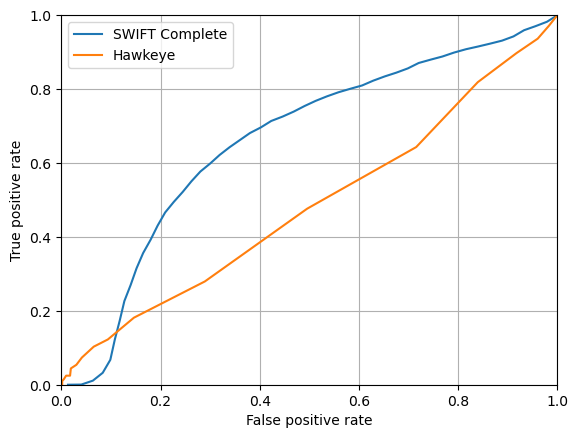

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import auc

# 2. Parsing the data
# (In a real scenario, you'd read this from a file or a list of dictionaries)
# I'll simulate the parsed results based on your input:
# data_points = [
#     {"tp": 0, "fp": 99, "tn": 7354, "fn": 2448},
#     {"tp": 2, "fp": 298, "tn": 7155, "fn": 2446},
#     # ... include all points from your list ...
#     {"tp": 2447, "fp": 7453, "tn": 0, "fn": 1}
# ]

# Note: For the sake of the script, ensure 'data_points' contains all your values.
# Let's extract metrics:
precisions = []
recalls = []
fprs = []

for p in data_points:
    # Precision = TP / (TP + FP)
    precision = p['tp'] / (p['tp'] + p['fp']) if (p['tp'] + p['fp']) > 0 else 1.0
    # Recall (Sensitivity/TPR) = TP / (TP + FN)
    recall = p['tp'] / (p['tp'] + p['fn']) if (p['tp'] + p['fn']) > 0 else 0.0
    # False Positive Rate = FP / (FP + TN)
    fpr = p['fp'] / (p['fp'] + p['tn']) if (p['fp'] + p['tn']) > 0 else 0.0
    
    precisions.append(precision)
    recalls.append(recall)
    fprs.append(fpr)

# Note: For the sake of the script, ensure 'data_points' contains all your values.
# Let's extract metrics:
precisions_2 = []
recalls_2 = []
fprs_2 = []

for p in data_points_2:
    # Precision = TP / (TP + FP)
    precision = p['tp'] / (p['tp'] + p['fp']) if (p['tp'] + p['fp']) > 0 else 1.0
    # Recall (Sensitivity/TPR) = TP / (TP + FN)
    recall = p['tp'] / (p['tp'] + p['fn']) if (p['tp'] + p['fn']) > 0 else 0.0
    # False Positive Rate = FP / (FP + TN)
    fpr = p['fp'] / (p['fp'] + p['tn'])
    
    precisions_2.append(precision)
    recalls_2.append(recall)
    fprs_2.append(fpr)


plt.plot(fprs_2, recalls_2, label="SWIFT Complete")
plt.plot(fprs, recalls, label="Hawkeye")
plt.xlim([0,1])
plt.ylim([0,1])
plt.grid()
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="upper left")
plt.show()

In [ ]:
# ax1.set_xlabel('Recall')
# ax1.set_ylabel('Precision')
# ax1.set_title('Precision-Recall Curve')
# ax1.legend(loc="lower left")
# ax1.grid(alpha=0.3)

# # ROC Curve (FPR vs TPR/Recall)
# ax2.plot(fprs, recalls, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random line
# ax2.set_xlabel('False Positive Rate')
# ax2.set_ylabel('True Positive Rate (Recall)')
# ax2.set_title('ROC Curve')
# ax2.legend(loc="lower right")
# ax2.grid(alpha=0.3)

# plt.tight_layout()
# plt.show()

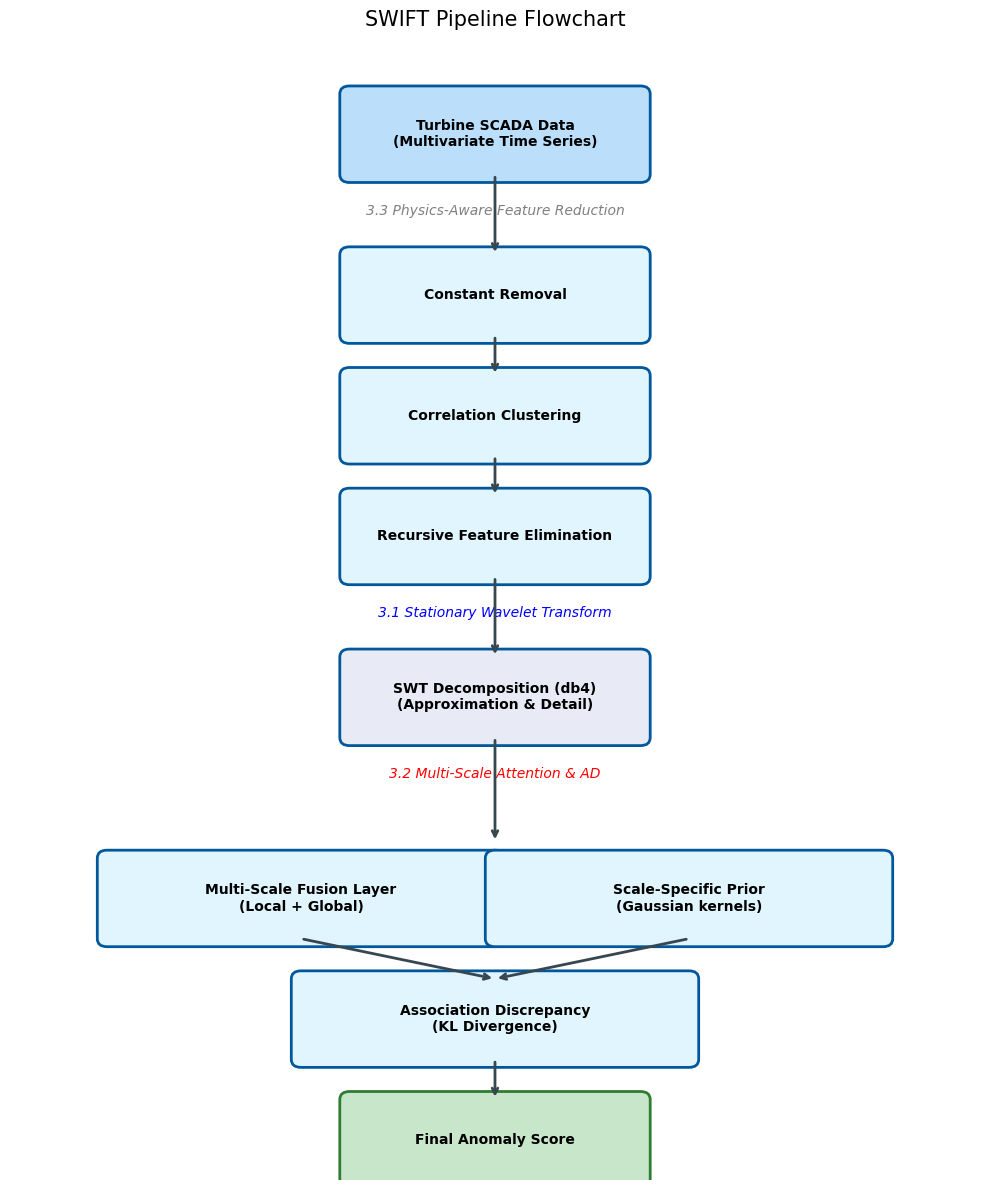

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_swift_pipeline():
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 14)
    ax.axis('off')

    # Helper function to draw a box
    def draw_box(text, x, y, width=3, height=1, color='#E1F5FE', ec='#01579B'):
        rect = patches.FancyBboxPatch((x-width/2, y-height/2), width, height, 
                                      boxstyle="round,pad=0.1", fc=color, ec=ec, lw=2)
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')

    # Helper to draw arrows
    def draw_arrow(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2, color='#37474F'))

    # 1. Start: SCADA Data
    draw_box("Turbine SCADA Data\n(Multivariate Time Series)", 5, 13, color='#BBDEFB')

    # 2. Feature Reduction Section
    ax.text(5, 12, "3.3 Physics-Aware Feature Reduction", ha='center', color='gray', style='italic')
    draw_box("Constant Removal", 5, 11)
    draw_box("Correlation Clustering", 5, 9.5)
    draw_box("Recursive Feature Elimination", 5, 8)

    # 3. SWT Module
    ax.text(5, 7, "3.1 Stationary Wavelet Transform", ha='center', color='blue', style='italic')
    draw_box("SWT Decomposition (db4)\n(Approximation & Detail)", 5, 6, color='#E8EAF6')

    # 4. MSA & AD
    ax.text(5, 5, "3.2 Multi-Scale Attention & AD", ha='center', color='red', style='italic')
    draw_box("Multi-Scale Fusion Layer\n(Local + Global)", 3, 3.5, width=4)
    draw_box("Scale-Specific Prior\n(Gaussian kernels)", 7, 3.5, width=4)
    draw_box("Association Discrepancy\n(KL Divergence)", 5, 2, width=4)

    # 5. Output
    draw_box("Final Anomaly Score", 5, 0.5, color='#C8E6C9', ec='#2E7D32')

    # Connect the dots
    draw_arrow(5, 12.5, 5, 11.5)
    draw_arrow(5, 10.5, 5, 10)
    draw_arrow(5, 9, 5, 8.5)
    draw_arrow(5, 7.5, 5, 6.5)
    draw_arrow(5, 5.5, 5, 4.2)
    draw_arrow(3, 3, 5, 2.5)
    draw_arrow(7, 3, 5, 2.5)
    draw_arrow(5, 1.5, 5, 1)

    plt.title("SWIFT Pipeline Flowchart", fontsize=15, pad=20)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    draw_swift_pipeline()